In [1]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


I explored the dataset by checking its shape, columns, missing values, and sentiment distribution.

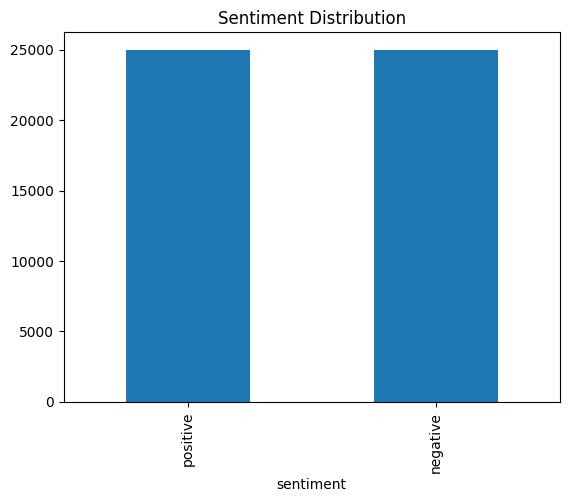

In [3]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
df['cleaned_review'] = df['review'].apply(preprocess_text)
df.head()

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [6]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [1]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [6]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [7]:
df['cleaned_review'] = df['review'].apply(preprocess_text)
df[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...,positive
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...,positive
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...,positive
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...,positive


In [8]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df[['sentiment', 'label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [9]:
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 40000
Testing data: 10000


In [10]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape:", X_test_bow.shape)

BoW train shape: (40000, 5000)
BoW test shape: (10000, 5000)


In [11]:
lr_bow = LogisticRegression(max_iter=1000)
nb_bow = MultinomialNB()
dt_bow = DecisionTreeClassifier(random_state=42)

lr_bow.fit(X_train_bow, y_train)
nb_bow.fit(X_train_bow, y_train)
dt_bow.fit(X_train_bow, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("\n" + name)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return [name, acc, prec, rec, f1]

In [13]:
results = []

results.append(evaluate_model("Logistic Regression + BoW", lr_bow, X_test_bow, y_test))
results.append(evaluate_model("Naive Bayes + BoW", nb_bow, X_test_bow, y_test))
results.append(evaluate_model("Decision Tree + BoW", dt_bow, X_test_bow, y_test))


Logistic Regression + BoW
Accuracy : 0.8674
Precision: 0.8675
Recall   : 0.8674
F1 Score : 0.8674

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      4961
           1       0.86      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Naive Bayes + BoW
Accuracy : 0.8438
Precision: 0.8439
Recall   : 0.8438
F1 Score : 0.8438

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      4961
           1       0.85      0.84      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


Decision Tree + BoW
Accuracy : 0.7224
Precision: 0.7225
Recall   : 0.7224
F1 Score : 0.7224

Classificati

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (40000, 5000)
TF-IDF test shape: (10000, 5000)


In [15]:
lr_tfidf = LogisticRegression(max_iter=1000)
nb_tfidf = MultinomialNB()
dt_tfidf = DecisionTreeClassifier(random_state=42)

lr_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf.fit(X_train_tfidf, y_train)
dt_tfidf.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
results.append(evaluate_model("Logistic Regression + TF-IDF", lr_tfidf, X_test_tfidf, y_test))
results.append(evaluate_model("Naive Bayes + TF-IDF", nb_tfidf, X_test_tfidf, y_test))
results.append(evaluate_model("Decision Tree + TF-IDF", dt_tfidf, X_test_tfidf, y_test))


Logistic Regression + TF-IDF
Accuracy : 0.8838
Precision: 0.8842
Recall   : 0.8838
F1 Score : 0.8838

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Naive Bayes + TF-IDF
Accuracy : 0.8459
Precision: 0.8459
Recall   : 0.8459
F1 Score : 0.8459

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4961
           1       0.84      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Decision Tree + TF-IDF
Accuracy : 0.7218
Precision: 0.7219
Recall   : 0.7218
F1 Score : 0.7218

Cla

In [17]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,Logistic Regression + TF-IDF,0.8838,0.884184,0.8838,0.883754
0,Logistic Regression + BoW,0.8674,0.867486,0.8674,0.867382
4,Naive Bayes + TF-IDF,0.8459,0.845937,0.8459,0.845887
1,Naive Bayes + BoW,0.8438,0.843933,0.8438,0.843798
2,Decision Tree + BoW,0.7224,0.722484,0.7224,0.722400
5,Decision Tree + TF-IDF,0.7218,0.721881,0.7218,0.721801


In [18]:
best_model = results_df.iloc[0]
print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression + TF-IDF
Accuracy                           0.8838
Precision                        0.884184
Recall                             0.8838
F1 Score                         0.883754
Name: 3, dtype: object


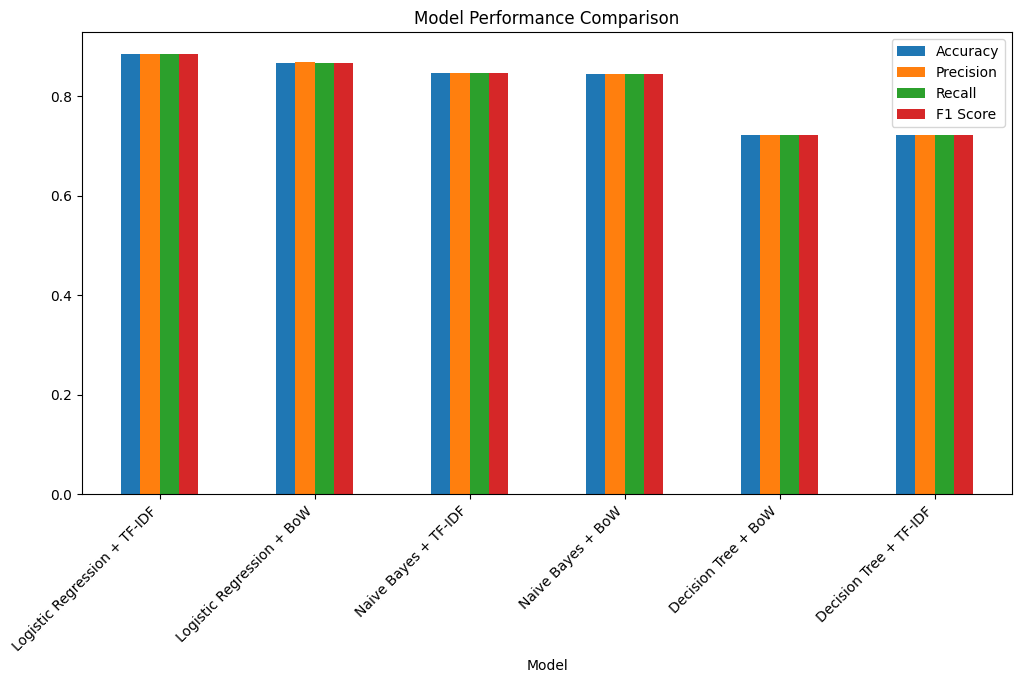

In [19]:
results_df.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
print("""
Conclusion:
1. I performed preprocessing on the text data using lowercasing, HTML removal,
   special character removal, stopword removal, and stemming.
2. I used both Bag of Words and TF-IDF for feature extraction.
3. I trained three models: Logistic Regression, Naive Bayes, and Decision Tree.
4. I evaluated the models using Accuracy, Precision, Recall, and F1 Score.
5. Based on the comparison, the best-performing model was selected.
""")


Conclusion:
1. I performed preprocessing on the text data using lowercasing, HTML removal,
   special character removal, stopword removal, and stemming.
2. I used both Bag of Words and TF-IDF for feature extraction.
3. I trained three models: Logistic Regression, Naive Bayes, and Decision Tree.
4. I evaluated the models using Accuracy, Precision, Recall, and F1 Score.
5. Based on the comparison, the best-performing model was selected.



Title

Sentiment Analysis using NLP Pipeline and ML Models

Objective

To build an end-to-end sentiment analysis system using NLP preprocessing, feature engineering, and machine learning models.

Dataset

I used the IMDb movie reviews dataset containing review text and sentiment labels.

Data Understanding

I checked the dataset shape, columns, missing values, and class distribution.

Preprocessing

I cleaned the text by lowercasing, removing HTML tags, removing special characters, removing stopwords, and applying stemming.

Feature Engineering

I converted the cleaned text into numerical vectors using Bag of Words and TF-IDF.

Models Used

1. Logistic Regression
2. Naive Bayes
3. Decision Tree

Evaluation Metrics

1. Accuracy
2. Precision
3. Recall
4. F1 Score
**bold text**
Conclusion

The best-performing model was selected after comparing all models on both BoW and TF-IDF features.

In this task, I built a complete sentiment analysis pipeline using NLP preprocessing and machine learning models. I applied Bag of Words and TF-IDF for feature extraction and trained Logistic Regression, Naive Bayes, and Decision Tree models. After evaluation using Accuracy, Precision, Recall, and F1 Score, I compared their performance and identified the best-performing model.